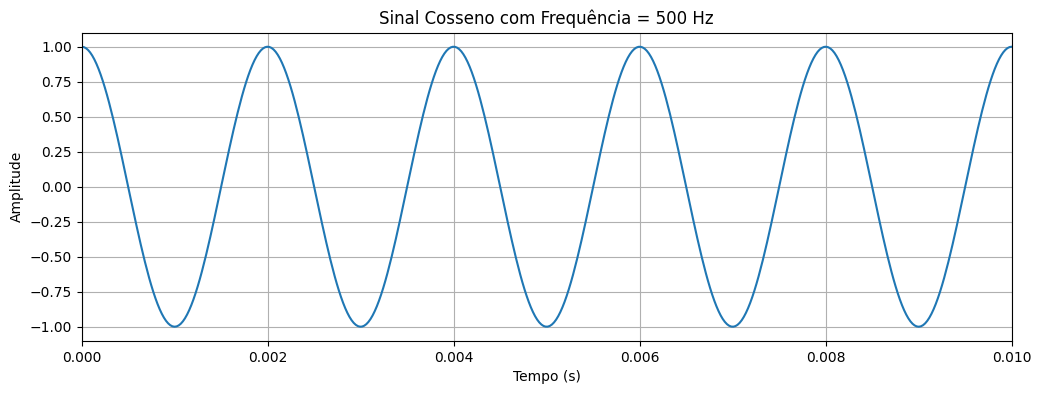

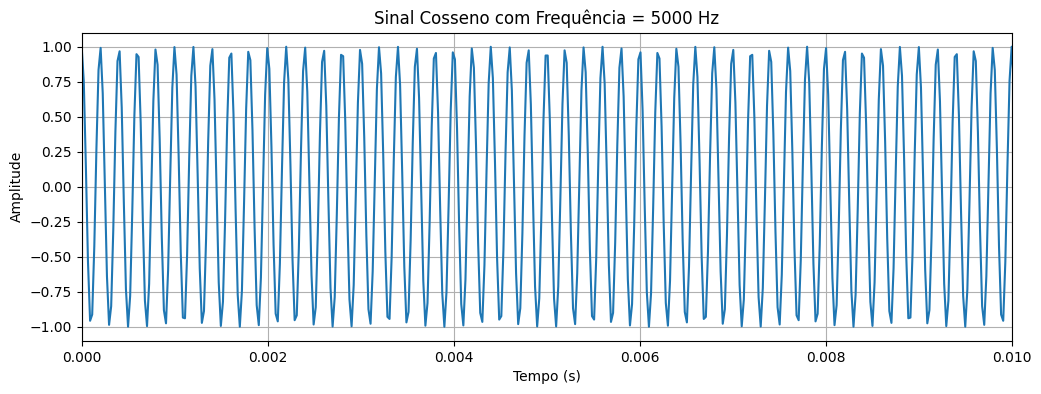

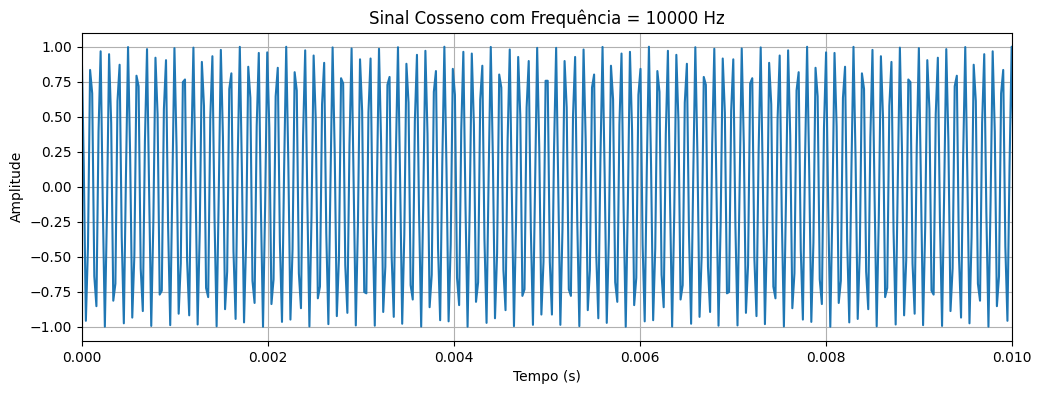

Audios da onda de 500 Hz...


Audios da onda de 5000 Hz...


Audios da onda de 10000 Hz...


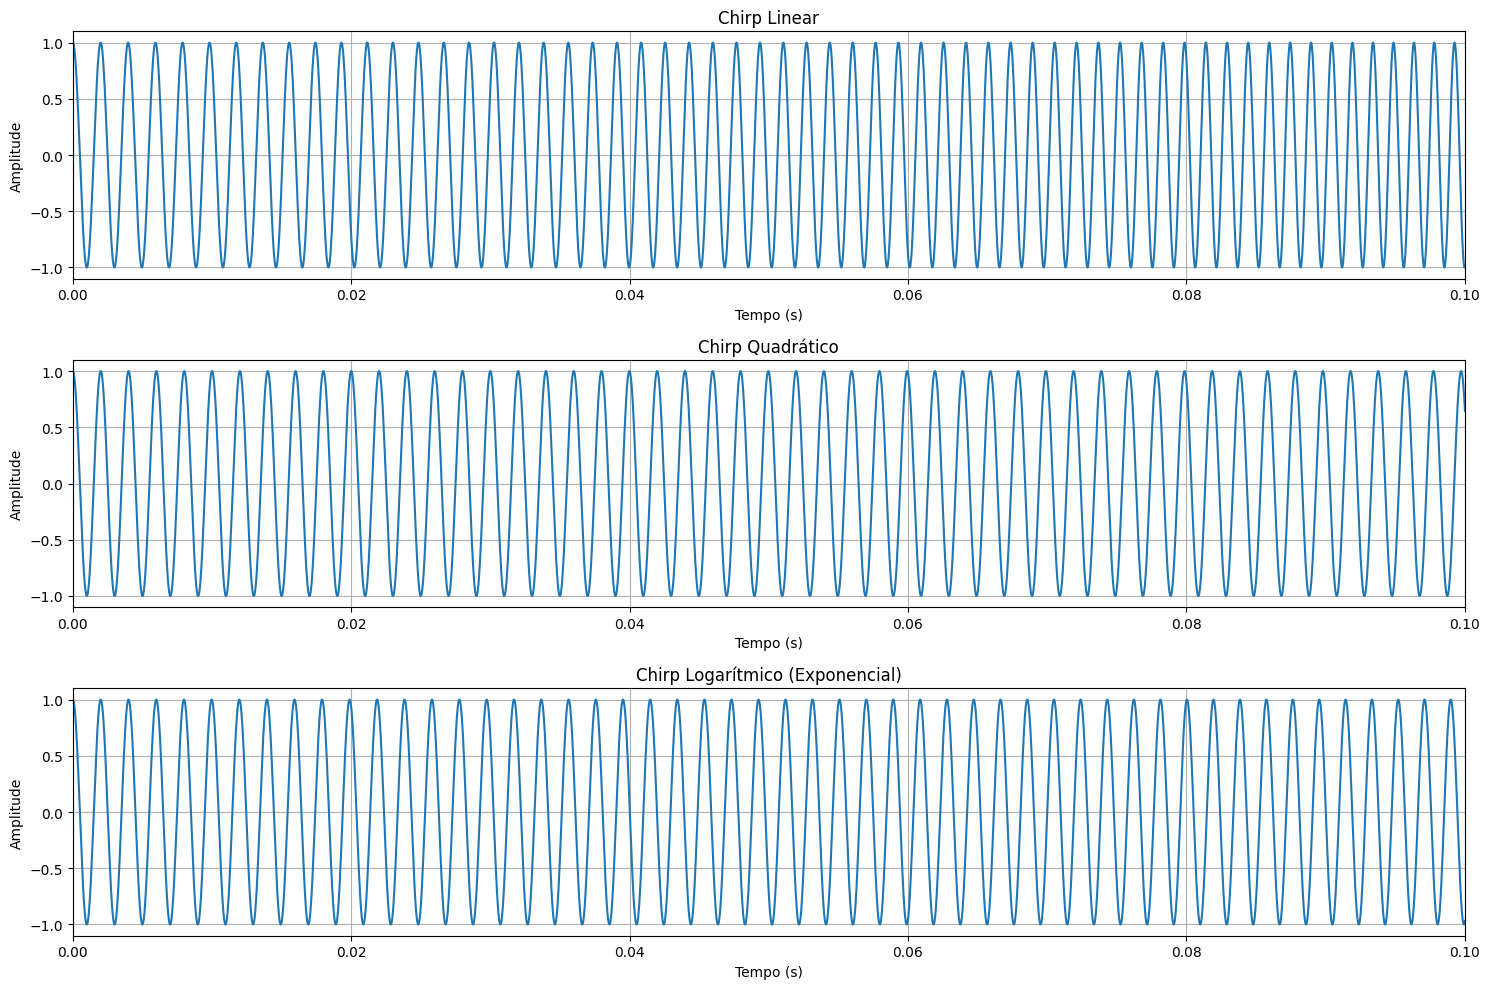

Áudios dos chirps:
Chirp Linear...


Chirp Quadrático...


Chirp Logarítmico...


Os gráficos dos sinais chirp foram gerados e exibidos.


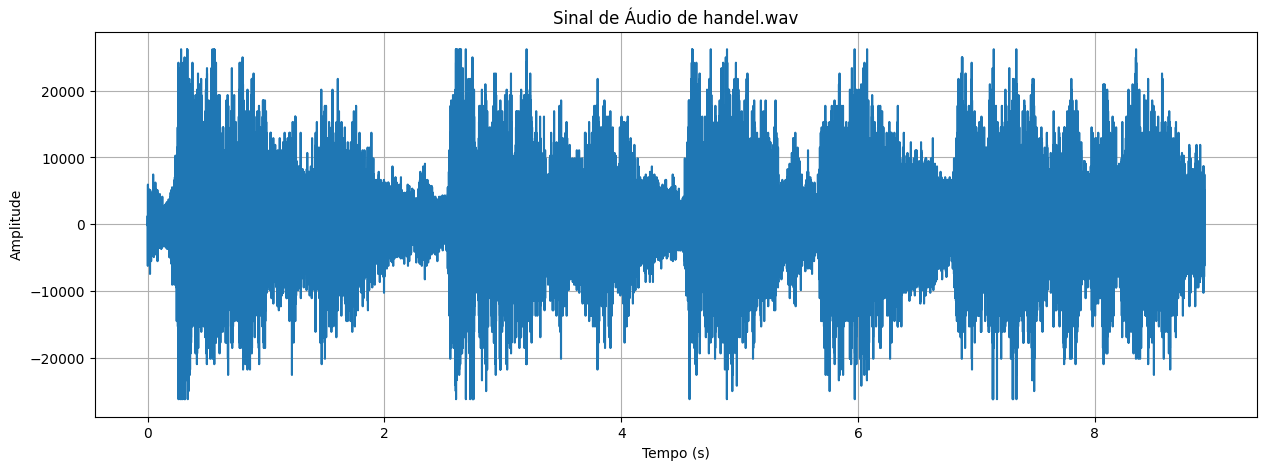

Áudio Original:


Áudio com o dobro da frequência de amostragem:


Áudio com o quádruplo da frequência de amostragem:


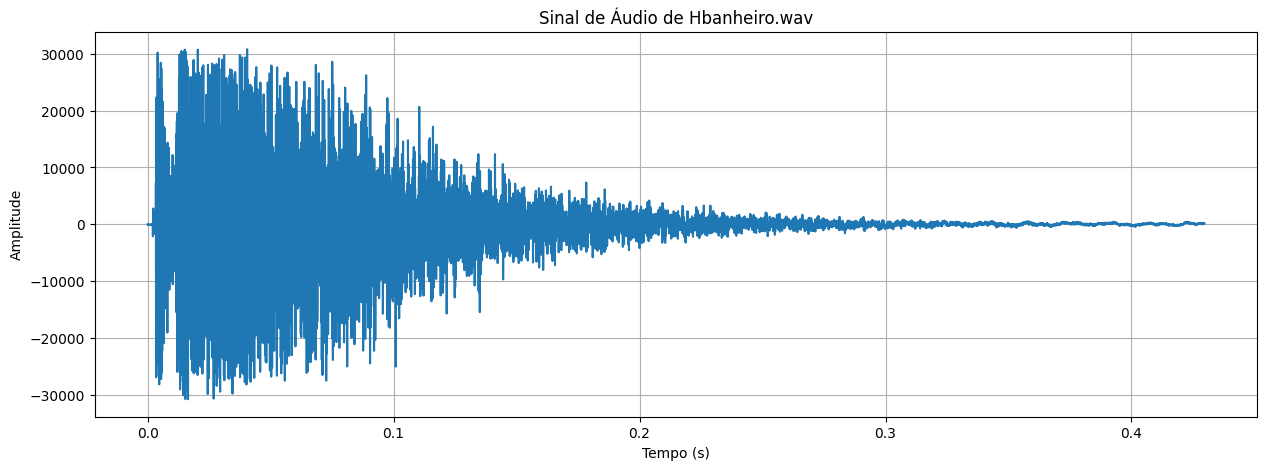

Áudio H_banheiro:


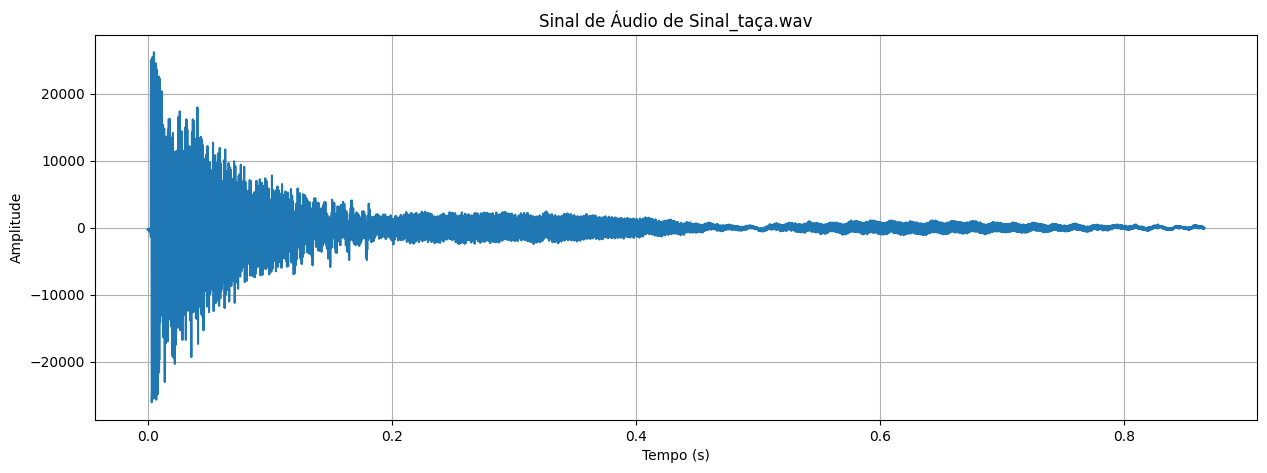

Áudio sinal_taca:


Áudio handel_convoluido:


Áudio taca_convoluido:


In [ ]:
import numpy
import matplotlib.pyplot
from IPython.display import Audio, display
from scipy.signal import chirp, resample_poly
from scipy.io import wavfile
import pandas as pd

# Definindo váriaveis para a duração do sinal e para a frequencia de amostragem:

duracaox = 5
freq_amostragem = 44100

# Criação o Eixo do Tempo t

t = numpy.linspace(0, duracaox, int(duracaox * freq_amostragem), endpoint=False)

# Gerar e Plotar Sinais x(t) para as Diferentes Frequências fs

frequencias = [500, 5000, 10000]

# Geração das ondas cossenoides

cossine_waves = []
for freq in frequencias:
  wave = numpy.cos(2 * numpy.pi * freq * t)
  cossine_waves.append(wave) #gurda a onda gerada

# 1)A) Gerar os gráficos:

for i, wave in enumerate(cossine_waves) :
  matplotlib.pyplot.figure(figsize=(12, 4)) # Aumenta um pouco o tamanho da figura
  matplotlib.pyplot.plot(t, wave)
  matplotlib.pyplot.title(f'Sinal Cosseno com Frequência = {frequencias[i]} Hz')
  matplotlib.pyplot.xlabel('Tempo (s)')
  matplotlib.pyplot.ylabel('Amplitude')
  matplotlib.pyplot.grid(True)
  matplotlib.pyplot.xlim(0, 0.01) # Limita o eixo X de 0 a 0.01 segundos
  matplotlib.pyplot.show() # Exibe o gráfico para esta frequência

# !!! CORREÇÃO AQUI: Limitar o eixo X para visualizar a onda !!!
# Para 500 Hz, 0.01s mostra 5 ciclos (1/500 = 0.002s por ciclo)
# Para 5000 Hz, 0.001s mostra 5 ciclos (1/5000 = 0.0002s por ciclo)

# 1)B) Tocar audio dos sinais gerados:

for i, wave in enumerate(cossine_waves):
    # Normalizar a amplitude para evitar clipping e ter um bom volume
    normalized_wave = wave / numpy.max(numpy.abs(wave))
    print(f"Audios da onda de {frequencias[i]} Hz...")
    display(Audio(data=normalized_wave, rate=freq_amostragem))

# C) comentarios

# 2) Definindo parametros iniciais:

f0 = 500
f1 = 10000

# 2)A)

# Geração do sinal chirp linear

linear_chirp = chirp(t, f0=f0, f1=f1, t1=duracaox, method='linear')

# Geração do sinal chirp quadrático
quadratic_chirp = chirp(t, f0=f0, f1=f1, t1=duracaox, method='quadratic')

# Geração do sinal chirp logarítmico (exponencial)
logarithmic_chirp = chirp(t, f0=f0, f1=f1, t1=duracaox, method='logarithmic')

# Gerar os gráficos dos chirps
matplotlib.pyplot.figure(figsize=(15, 10))

matplotlib.pyplot.subplot(3, 1, 1)
matplotlib.pyplot.plot(t, linear_chirp)
matplotlib.pyplot.title('Chirp Linear')
matplotlib.pyplot.xlabel('Tempo (s)')
matplotlib.pyplot.ylabel('Amplitude')
matplotlib.pyplot.xlim(0, 0.1) # Limita o eixo X para melhor visualização
matplotlib.pyplot.grid(True)

matplotlib.pyplot.subplot(3, 1, 2)
matplotlib.pyplot.plot(t, quadratic_chirp)
matplotlib.pyplot.title('Chirp Quadrático')
matplotlib.pyplot.xlabel('Tempo (s)')
matplotlib.pyplot.ylabel('Amplitude')
matplotlib.pyplot.xlim(0, 0.1) # Limita o eixo X para melhor visualização
matplotlib.pyplot.grid(True)

matplotlib.pyplot.subplot(3, 1, 3)
matplotlib.pyplot.plot(t, logarithmic_chirp)
matplotlib.pyplot.title('Chirp Logarítmico (Exponencial)')
matplotlib.pyplot.xlabel('Tempo (s)')
matplotlib.pyplot.ylabel('Amplitude')
matplotlib.pyplot.xlim(0, 0.1) # Limita o eixo X para melhor visualização
matplotlib.pyplot.grid(True)

matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

# 2)B)

print("Áudios dos chirps:")

# Tocar áudio do chirp linear

print("Chirp Linear...")
display(Audio(data=linear_chirp, rate=freq_amostragem))

# Tocar áudio do chirp quadrático

print("Chirp Quadrático...")
display(Audio(data=quadratic_chirp, rate=freq_amostragem))

# Tocar áudio do chirp logarítmico

print("Chirp Logarítmico...")
display(Audio(data=logarithmic_chirp, rate=freq_amostragem))

print("Os gráficos dos sinais chirp foram gerados e exibidos.")

# 3)A) Carregar e Plotar Áudio:

file_path = 'handel.wav'
fs, data = wavfile.read(file_path)

duracaohandel = len(data) / fs
t_audio = numpy.linspace(0, duracaohandel, len(data), endpoint=False)

# Gerar os graficos

matplotlib.pyplot.figure(figsize=(15, 5))
matplotlib.pyplot.plot(t_audio, data)
matplotlib.pyplot.title('Sinal de Áudio de handel.wav')
matplotlib.pyplot.xlabel('Tempo (s)')
matplotlib.pyplot.ylabel('Amplitude')
matplotlib.pyplot.grid(True)
matplotlib.pyplot.show()

# 3)B) Gerar os audios:

# Normalizar o áudio para evitar clipping e garantir um bom volume
normalized_data = data / numpy.max(numpy.abs(data))

print("Áudio Original:")
display(Audio(data=normalized_data, rate=fs))

print("Áudio com o dobro da frequência de amostragem:")
display(Audio(data=normalized_data, rate=2 * fs))

print("Áudio com o quádruplo da frequência de amostragem:")
display(Audio(data=normalized_data, rate=4 * fs))

#5)A) Carregar e Plotar Áudio (banheiro)

hbanheiro = 'h_banheiro.wav'
fb, data = wavfile.read(hbanheiro)

duracaobanheiro = len(data) / fb
t_audioB = numpy.linspace(0, duracaobanheiro, len(data), endpoint=False)

# Gerar os graficos

matplotlib.pyplot.figure(figsize=(15, 5))
matplotlib.pyplot.plot(t_audioB, data)
matplotlib.pyplot.title('Sinal de Áudio de Hbanheiro.wav')
matplotlib.pyplot.xlabel('Tempo (s)')
matplotlib.pyplot.ylabel('Amplitude')
matplotlib.pyplot.grid(True)
matplotlib.pyplot.show()

# Gerar audio (banheiro):

# Normalizar o áudio para evitar clipping e garantir um bom volume
banheiro_normalizado = data / numpy.max(numpy.abs(data))

print("Áudio H_banheiro:")
display(Audio(data=banheiro_normalizado, rate=fb))

#Carregar e Plotar Áudio (taça)

sinaltaca = 'sinal_taca.wav'
ft, data = wavfile.read(sinaltaca)

duracaotaca = len(data) / ft
t_audioT = numpy.linspace(0, duracaotaca, len(data), endpoint=False)

# Gerar os graficos

matplotlib.pyplot.figure(figsize=(15, 5))
matplotlib.pyplot.plot(t_audioT, data)
matplotlib.pyplot.title('Sinal de Áudio de Sinal_taça.wav')
matplotlib.pyplot.xlabel('Tempo (s)')
matplotlib.pyplot.ylabel('Amplitude')
matplotlib.pyplot.grid(True)
matplotlib.pyplot.show()

# Gerar audio (Taça):

# Normalizar o áudio para evitar clipping e garantir um bom volume
taca_normalizado = data / numpy.max(numpy.abs(data))

print("Áudio sinal_taca:")
display(Audio(data=taca_normalizado, rate=ft))

# 6) Dica: Para convoluir dois sinais, eles precisam estar na mesma frequˆencia de amostragem.
# Ajustar a frequencia de amostragem do sinal handel:

handel_reamostrado = resample_poly(normalized_data, fb, fs)

# Convolução handel (reamostrado) com h_banheiro

handel_convoluido = numpy.convolve(handel_reamostrado, banheiro_normalizado, mode='full')

# Convolução handel (reamostrado) com sinal_taca

taca_convoluido = numpy.convolve(taca_normalizado, banheiro_normalizado, mode='full')

# Gerar audio Handel_convoluido:
# Normalizar o áudio para evitar clipping e garantir um bom volume
handel_convoluido_normalizado = handel_convoluido / numpy.max(numpy.abs(handel_convoluido))

print("Áudio handel_convoluido:")
display(Audio(data=handel_convoluido_normalizado, rate=fb))


# Gerar audio taca_convoluido:
# Normalizar o áudio para evitar clipping e garantir um bom volume
taca_convoluido_normalizado = taca_convoluido / numpy.max(numpy.abs(taca_convoluido))

print("Áudio taca_convoluido:")
display(Audio(data=taca_convoluido_normalizado, rate=fb))

